In [63]:
!pip install pytorch_forecasting

In [64]:
import pandas as pd

df = pd.read_csv('/content/MOCK_DATA_FOR_TIME_SERIES.csv')
display(df.head())

,baranggay_id,year,date,quarter,water,trees,crops,grass,shrubs-and-scrubs,flooded vegetation,built-up areas,bare ground,snow-and-ice
0,1,2016,1/1/2016,1,14.48,0.03,3.18,34.09,24.81,2.70,9.50,0.94,10.28
1,1,2016,4/1/2016,2,2.90,5.13,0.06,34.04,2.28,13.61,37.99,3.67,0.32
2,1,2016,7/1/2016,3,1.31,7.93,31.65,2.10,0.72,18.82,5.81,16.11,15.55
3,1,2016,10/1/2016,4,1.93,34.44,0.32,6.81,4.31,6.98,15.16,9.41,20.65
4,1,2017,1/1/2017,1,14.52,1.80,26.20,3.03,11.47,1.75,14.48,9.33,17.41


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# Task
Prepare the provided time series dataset for multivariate forecasting, starting with converting the 'date' column to datetime objects and analyzing the panel data structure by inspecting unique 'baranggay_id' and time points. Then, identify all potential time-series features by excluding identifier columns, visualize the trends for selected 'baranggay_id' and features like 'water' and 'trees', and restructure the data for multivariate time series forecasting, concluding with an outline of the next steps for implementing a DeepVAR model.

## Understand Data Structure

### Subtask:
Convert the 'date' column to datetime objects and then inspect the unique 'baranggay_id' entries and the number of time points for each, to confirm the panel data structure.


**Reasoning**:
Convert the 'date' column to datetime objects, then inspect the unique 'baranggay_id' entries and the number of time points for each to confirm the panel data structure.



In [65]:
df['date'] = pd.to_datetime(df['date'])

print(f"Number of unique baranggay_id: {df['baranggay_id'].nunique()}")

print("\nNumber of time points per baranggay_id:")
print(df.groupby('baranggay_id').size())

Number of unique baranggay_id: 5

Number of time points per baranggay_id:
baranggay_id
1    40
2    40
3    40
4    40
5    40
dtype: int64


## Identify Time Series Features

### Subtask:
Automatically identify all potential time-series features (e.g., 'water', 'trees', 'crops') from the DataFrame by excluding identifier columns like 'baranggay_id', 'year', 'date', and 'quarter'.


**Reasoning**:
To identify the potential time-series features, I will define a list of identifier columns and then filter out these columns from the DataFrame's columns to get the remaining features. Finally, I will print the identified features.



In [66]:
identifier_columns = ['baranggay_id', 'year', 'date', 'quarter']
all_columns = df.columns.tolist()

time_series_features = [col for col in all_columns if col not in identifier_columns]

print("Potential time-series features:")
print(time_series_features)

Potential time-series features:
['water', 'trees', 'crops', 'grass', 'shrubs-and-scrubs', 'flooded vegetation', 'built-up areas', 'bare ground', 'snow-and-ice']


## Visualize Sample Time Series

### Subtask:
Generate a plot to visualize the time series for a few selected 'baranggay_id' and a couple of key features (e.g., 'water', 'trees') to observe their trends and patterns. Legends will be provided for clarity.


**Reasoning**:
To visualize the time series for selected 'baranggay_id' and features, I will first import the necessary plotting libraries, then define the chosen `baranggay_id`s and features. After that, I will create subplots and iterate through each selected `baranggay_id` and feature to generate line plots showing their trends over time, ensuring to add relevant labels, titles, and legends for clarity.



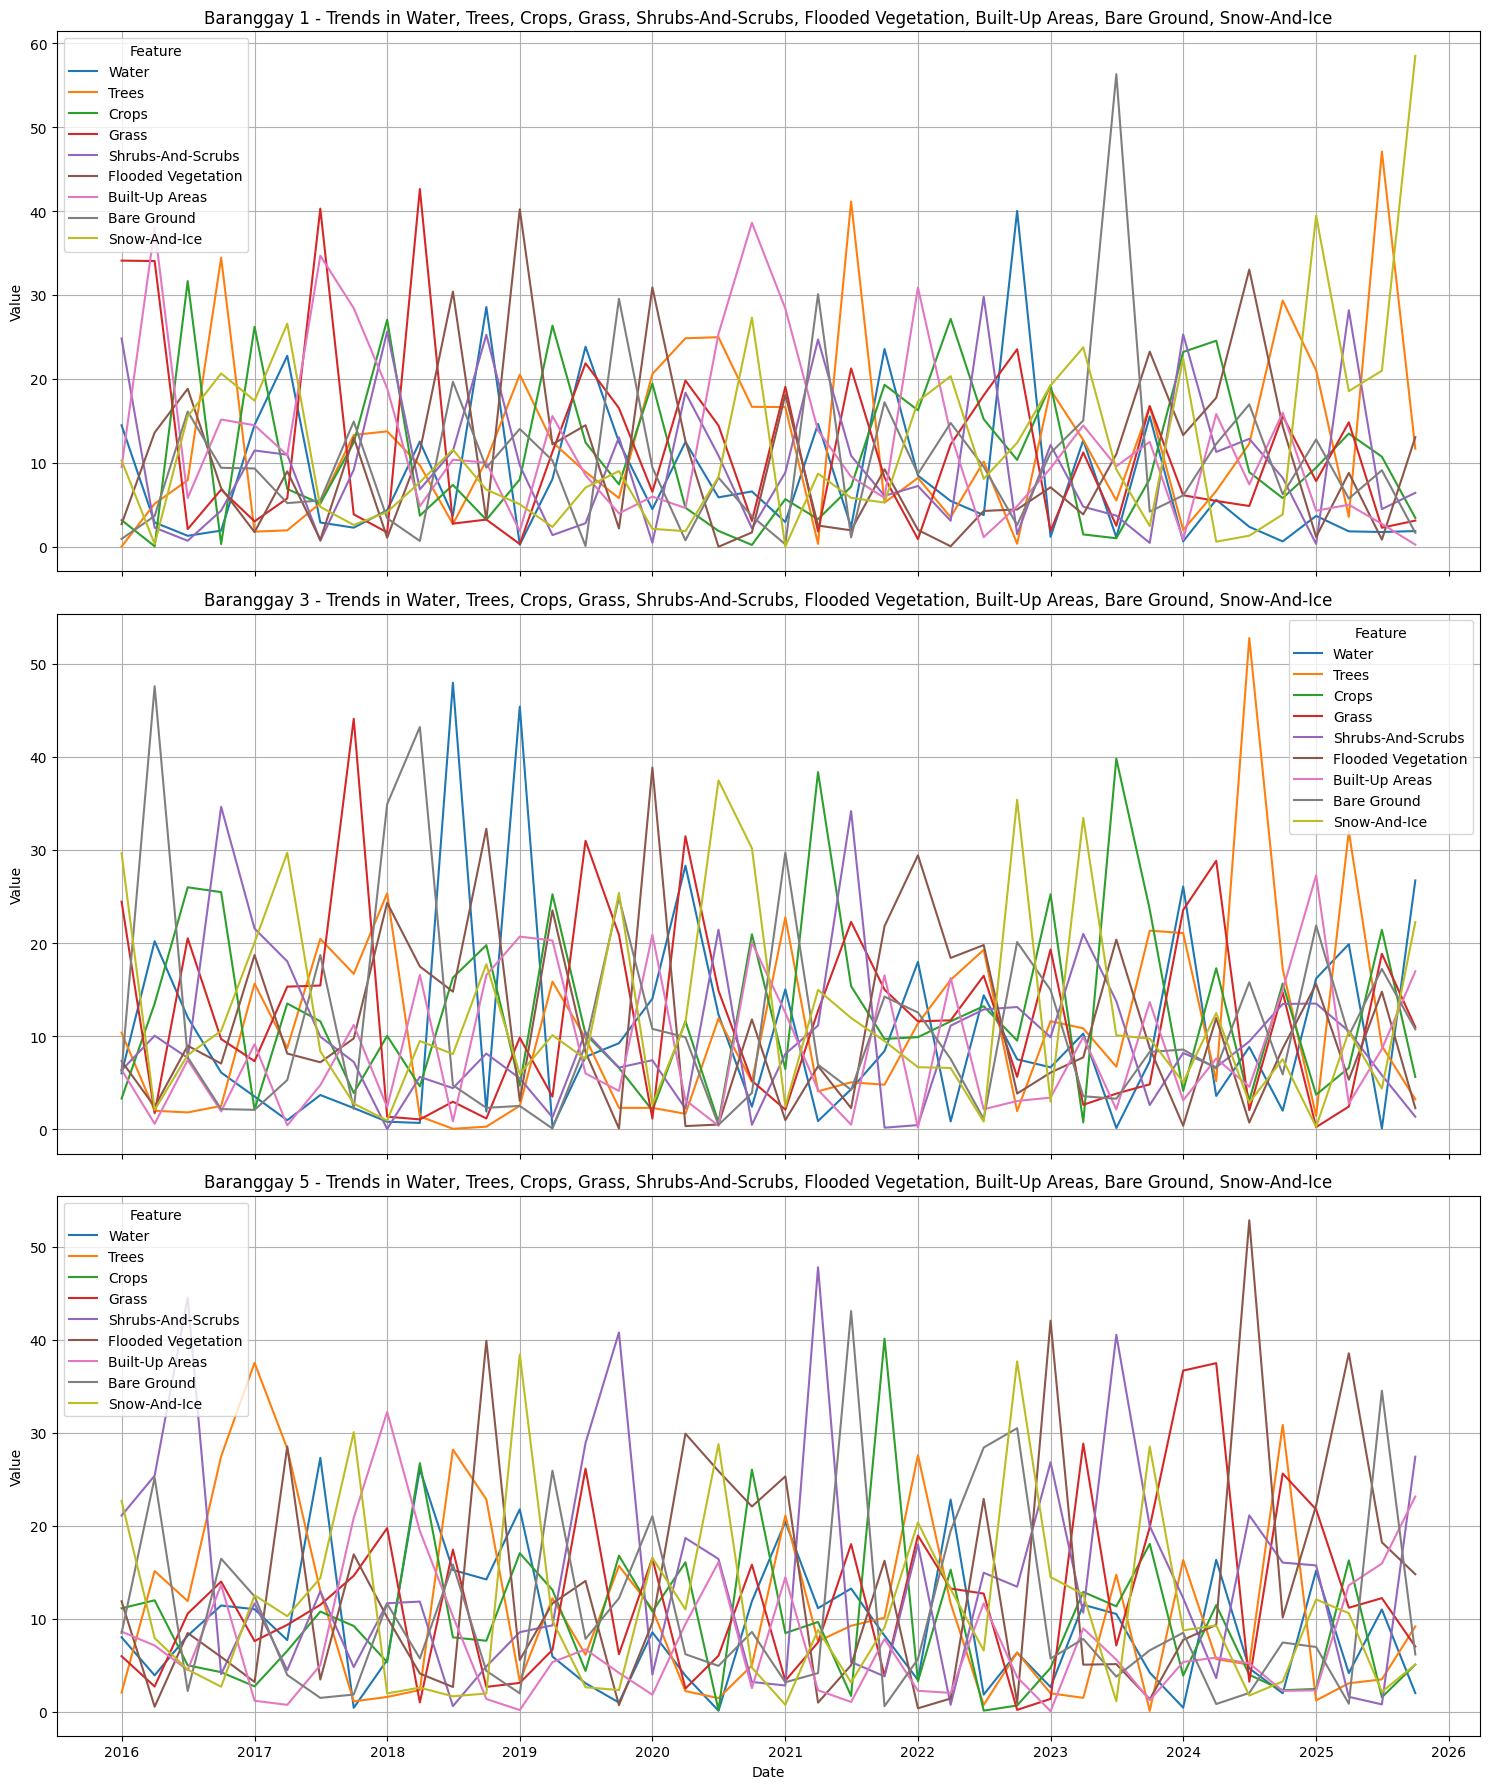

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Choose two or three distinct baranggay_id values
selected_baranggays = [1, 3, 5]

# 3. Choose two key time-series features to visualize
selected_features = ['water', 'trees', 'crops', 'grass', 'shrubs-and-scrubs', 'flooded vegetation', 'built-up areas', 'bare ground', 'snow-and-ice']
# 4. Create a figure and axes for the plots
# Determine the number of rows needed based on the number of selected baranggays
num_rows = len(selected_baranggays)
fig, axes = plt.subplots(num_rows, 1, figsize=(15, 6 * num_rows), sharex=True)

# Ensure axes is an array even if num_rows is 1
if num_rows == 1:
    axes = [axes]

# 5. For each selected baranggay_id
for i, baranggay_id in enumerate(selected_baranggays):
    baranggay_df = df[df['baranggay_id'] == baranggay_id].sort_values(by='date')

    # 6. For each filtered DataFrame, iterate through the chosen features and create a line plot
    for feature in selected_features:
        sns.lineplot(data=baranggay_df, x='date', y=feature, label=feature.replace('_', ' ').title(), ax=axes[i])

    # 7. Add appropriate labels and a title for each subplot
    axes[i].set_title(f'Baranggay {baranggay_id} - Trends in {', '.join([f.replace('_', ' ').title() for f in selected_features])}')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

    # 8. Add a legend to each plot
    axes[i].legend(title='Feature')

# Set common x-axis label
axes[-1].set_xlabel('Date')

# 9. Use plt.tight_layout() to ensure plots do not overlap and plt.show()
plt.tight_layout()
plt.show()

## Prepare Data for Forecasting

### Subtask:
Restructure the dataset to be suitable for multivariate time series forecasting models by setting a proper time index and ensuring consistency across different 'baranggay_id' series.


**Reasoning**:
To prepare the data for multivariate time series forecasting, I will first set the 'date' column as the index, then create a MultiIndex using 'baranggay_id' and 'date', sort the index, and finally create a new DataFrame `df_forecast` containing only the identified time series features.



In [68]:
df = df.set_index('date')
df_multiindex = df.set_index(['baranggay_id', df.index]).sort_index()
df_forecast = df_multiindex[time_series_features]

print("Shape of df_forecast:", df_forecast.shape)
display(df_forecast.head())

Shape of df_forecast: (200, 9)


water  trees  crops  grass  shrubs-and-scrubs  \
baranggay_id date                                                        
1            2016-01-01  14.48   0.03   3.18  34.09              24.81   
             2016-04-01   2.90   5.13   0.06  34.04               2.28   
             2016-07-01   1.31   7.93  31.65   2.10               0.72   
             2016-10-01   1.93  34.44   0.32   6.81               4.31   
             2017-01-01  14.52   1.80  26.20   3.03              11.47   

                         flooded vegetation  built-up areas  bare ground  \
baranggay_id date                                                          
1            2016-01-01                2.70            9.50         0.94   
             2016-04-01               13.61           37.99         3.67   
             2016-07-01               18.82            5.81        16.11   
             2016-10-01                6.98           15.16         9.41   
             2017-01-01                1.75           14.48         9.33   

                         snow-and-ice  
baranggay_id date                      
1            2016-01-01         10.28  
             2016-04-01          0.32  
             2016-07-01         15.55  
             2016-10-01         20.65  
             2017-01-01         17.41

## DeepVAR Model Considerations

### Subtask:
Outline the next steps required for implementing a DeepVAR-like model, which typically involves selecting an appropriate deep learning framework (e.g., PyTorch, TensorFlow) and a time series library (e.g., GluonTS), followed by defining the model architecture and training process.


### DeepVAR Model Considerations

To implement a DeepVAR-like model for multivariate time series forecasting, the following steps are crucial:

1.  **Select a Deep Learning Framework**: For this task, **PyTorch** is a suitable choice due to its flexibility, dynamic computation graph, and extensive community support, making it ideal for research and custom model development. TensorFlow is another viable option, offering strong production deployment capabilities.

2.  **Suggest a Time Series Library/Toolkit**: **GluonTS** (built on PyTorch and MXNet) or **Darts** (built on PyTorch and TensorFlow) are excellent choices. GluonTS provides a collection of probabilistic time series models, including DeepVAR, and abstractions for data handling, training, and evaluation, simplifying the implementation of complex forecasting models. Darts offers a unified API for various time series models and can integrate with popular deep learning frameworks.

3.  **Outline Key Components of DeepVAR Model Architecture**:
    *   **Recurrent Neural Networks (RNNs)**: DeepVAR models typically leverage RNN variants like LSTMs (Long Short-Term Memory) or GRUs (Gated Recurrent Units) to capture temporal dependencies within each individual time series.
    *   **Multivariate Handling**: To address the multivariate nature, the model typically processes each component (feature) of the time series simultaneously. A common approach is to use a shared RNN encoder for all variables, or parallel RNNs for each variable, followed by a decoder that models the joint distribution of future values.
    *   **Probabilistic Forecasting**: DeepVAR aims for probabilistic forecasts, meaning it outputs a probability distribution over future values rather than just a point estimate. This is often achieved by modeling the parameters (e.g., mean and variance) of a chosen distribution (e.g., Gaussian, Student's t) using the neural network's output.
    *   **Autoregressive Component**: The model incorporates an autoregressive structure, meaning the prediction for the next time step depends on previous predictions and observed values.

4.  **Describe the Training Process**:
    *   **Data Splitting**: The `df_forecast` dataset should be split into training, validation, and test sets. A common practice for time series data is to use a chronological split, where the training set consists of earlier data, the validation set follows, and the test set contains the most recent data to evaluate future performance realistically.
    *   **Loss Function**: For probabilistic forecasting, the loss function is often based on the negative log-likelihood of the observed data given the predicted probability distributions. For example, if using Gaussian distributions, the loss would be the negative log-likelihood of a Gaussian. This encourages the model to predict accurate means and variances.
    *   **Optimization**: Standard optimization algorithms like Adam or RMSprop are used to minimize the chosen loss function.
    *   **Hyperparameter Tuning**: Key hyperparameters include the number of layers in the RNN, the hidden state size, learning rate, batch size, and the length of the look-back window (context length). Techniques like grid search, random search, or Bayesian optimization can be employed for tuning.

5.  **Handling Dataset Characteristics**:
    *   **Seasonality and Trends**: DeepVAR models, particularly with RNNs, can inherently learn complex patterns like seasonality and trends from the data. However, explicit handling might involve:
        *   **Feature Engineering**: Adding features like sine/cosine transformations of the 'quarter' or 'year' to capture seasonality.
        *   **Preprocessing**: Differencing the series to make them stationary, or using detrending techniques, though modern deep learning models can often handle non-stationarity without explicit differencing.
        *   **Model Design**: Incorporating specific layers or attention mechanisms within the DeepVAR architecture to explicitly model long-term dependencies for trends or periodic patterns for seasonality.

## Final Task

### Subtask:
Summarize the data preparation and exploratory analysis, indicating the dataset's readiness for advanced time series modeling techniques like DeepVAR.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 5 unique `baranggay_id`s, each with a consistent 40 time points, confirming a balanced panel data structure suitable for time series analysis.
*   Nine potential time-series features were identified by excluding identifier columns: 'water', 'trees', 'crops', 'grass', 'shrubs-and-scrubs', 'flooded vegetation', 'built-up areas', 'bare ground', and 'snow-and-ice'.
*   Visualizations of 'water' and 'trees' trends for selected `baranggay_id`s (1, 3, 5) were successfully generated, allowing for observation of their temporal patterns.
*   The data has been successfully restructured into a MultiIndex DataFrame (`df_forecast`) with a shape of (200, 9), where the index consists of `baranggay_id` and `date`, making it ready for multivariate time series forecasting models.

### Insights or Next Steps

*   The dataset is now thoroughly prepared and structured for advanced multivariate time series modeling. The balanced panel data structure and identified features make it well-suited for models that can capture complex interdependencies across variables and entities.
*   The next logical step is to implement a DeepVAR-like model using a framework like PyTorch and a library such as GluonTS or Darts. This would involve defining an RNN-based architecture capable of probabilistic forecasting, splitting the data chronologically, and training the model using negative log-likelihood as the loss function, followed by hyperparameter tuning and evaluation.


## Install Libraries

### Subtask:
Install `pytorch_forecasting` and `pytorch_lightning` which are necessary for implementing the DeepVAR model.


**Reasoning**:
To install the necessary libraries for DeepVAR model implementation, I will first use pip to install `pytorch_forecasting`.



## Prepare Data for PyTorch Forecasting

### Subtask:
Convert the `df_forecast` DataFrame into a format suitable for `pytorch_forecasting.TimeSeriesDataSet`. This involves flattening the MultiIndex, adding the original `year` and `quarter` as features (if needed), and defining parameters like time index, group IDs (`baranggay_id`), and specifying static and time-varying covariates. The `max_encoder_length` and `max_prediction_length` will also be defined.


**Reasoning**:
First, I will reset the index of the `df_forecast` DataFrame, add a `time_idx` column for sequential time steps, and extract `year` and `quarter` as new columns, converting `quarter` to a string type, to prepare the data for `pytorch_forecasting.TimeSeriesDataSet`.



In [71]:
data = df_forecast.reset_index()

data['time_idx'] = data.groupby('baranggay_id').cumcount()

data['year'] = data['date'].dt.year
data['quarter'] = data['date'].dt.quarter.astype(str)
data['baranggay_id'] = data['baranggay_id'].astype(str)

max_encoder_length = 12
max_prediction_length = 4

print("Prepared data head:")
display(data.head())


Prepared data head:


,baranggay_id,date,water,trees,crops,grass,shrubs-and-scrubs,flooded vegetation,built-up areas,bare ground,snow-and-ice,time_idx,year,quarter
0,1,2016-01-01,14.48,0.03,3.18,34.09,24.81,2.70,9.50,0.94,10.28,0,2016,1
1,1,2016-04-01,2.90,5.13,0.06,34.04,2.28,13.61,37.99,3.67,0.32,1,2016,2
2,1,2016-07-01,1.31,7.93,31.65,2.10,0.72,18.82,5.81,16.11,15.55,2,2016,3
3,1,2016-10-01,1.93,34.44,0.32,6.81,4.31,6.98,15.16,9.41,20.65,3,2016,4
4,1,2017-01-01,14.52,1.80,26.20,3.03,11.47,1.75,14.48,9.33,17.41,4,2017,1


**Reasoning**:
Now that the data is prepared with `time_idx`, `year`, and `quarter` columns, I will import `TimeSeriesDataSet` and instantiate it with the specified parameters to create a training dataset suitable for `pytorch_forecasting`.



# Task
Configure the `TimeSeriesDataSet` for `pytorch_forecasting` using the `data` DataFrame, specifying 'time_idx' as the time index, 'baranggay_id' as the group ID, `time_series_features` as the target variables, 'baranggay_id' and 'quarter' as categorical covariates, and 'time_idx' and 'year' as numerical covariates, using the predefined `max_encoder_length` and `max_prediction_length`.

## Configure TimeSeriesDataSet

### Subtask:
Configure the `TimeSeriesDataSet` for `pytorch_forecasting` using the prepared `data` DataFrame, specifying the time index, group IDs ('baranggay_id'), target variables (`time_series_features`), and identifying categorical (`baranggay_id`, `quarter`) and numerical (`time_idx`, `year`) covariates. Define the `max_encoder_length` and `max_prediction_length` based on the previously set values.


**Reasoning**:
I will import the `TimeSeriesDataSet` class, calculate `max_time_idx` and `training_cutoff`, and then instantiate `TimeSeriesDataSet` with the prepared data and specified parameters to create the training dataset for `pytorch_forecasting`.



In [72]:
from pytorch_forecasting import TimeSeriesDataSet

max_time_idx = data['time_idx'].max()

training_cutoff = max_time_idx - max_prediction_length

training_set = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=time_series_features,
    group_ids=["baranggay_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["baranggay_id"],
    time_varying_known_categoricals=["quarter"],
    time_varying_known_reals=["time_idx", "year"],
    time_varying_unknown_reals=time_series_features,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

print("Training TimeSeriesDataSet configuration:")
print(training_set)

Training TimeSeriesDataSet configuration:
TimeSeriesDataSet[length=105](
	time_idx='time_idx',
	target=['water', 'trees', 'crops', 'grass', 'shrubs-and-scrubs', 'flooded vegetation', 'built-up areas', 'bare ground', 'snow-and-ice'],
	group_ids=['baranggay_id'],
	weight=None,
	max_encoder_length=12,
	min_encoder_length=12,
	min_prediction_idx=0,
	min_prediction_length=4,
	max_prediction_length=4,
	static_categoricals=['baranggay_id'],
	static_reals=None,
	time_varying_known_categoricals=['quarter'],
	time_varying_known_reals=['time_idx', 'year'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['water', 'trees', 'crops', 'grass', 'shrubs-and-scrubs', 'flooded vegetation', 'built-up areas', 'bare ground', 'snow-and-ice'],
	variable_groups=None,
	constant_fill_strategy=None,
	allow_missing_timesteps=False,
	lags=None,
	add_relative_time_idx=True,
	add_target_scales=True,
	add_encoder_length=True,
	target_normalizer=MultiNormalizer(
	normalizers=[GroupNormalizer(
	meth

## Create Training and Validation DataLoaders

### Subtask:
Split the `TimeSeriesDataSet` into training and validation datasets based on a chronological cutoff. Then, create `DataLoader` objects for both the training and validation sets to handle batching and data loading efficiently during model training.


**Reasoning**:
To create the validation dataset, I will use the `from_dataset` method on the `training_set`, filtering the original `data` for time indices greater than the `training_cutoff` and setting the `min_encoder_length` to `max_encoder_length`.



In [73]:
validation_set = TimeSeriesDataSet.from_dataset(
    training_set,
    data,
    min_encoder_length=max_encoder_length,
    stop_randomization=True,
    # filter out data points in the encoder that are after the cutoff
    # this is important to not leak data to the validation set
    predict_mode=True # set to predict_mode for validation set
)

batch_size = 32

train_dataloader = training_set.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=0
)

val_dataloader = validation_set.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0
)

print(f"Training DataLoader has {len(train_dataloader)} batches with batch size {batch_size}")
print(f"Validation DataLoader has {len(val_dataloader)} batches with batch size {batch_size}")

Training DataLoader has 3 batches with batch size 32
Validation DataLoader has 1 batches with batch size 32


## Initialize and Train the DeepAR Model

### Subtask:
Initialize the `DeepAR` model using the `TimeSeriesDataSet` and `pytorch_lightning.Trainer`. Configure the trainer with appropriate callbacks and parameters, such as the number of epochs and learning rate. Train the DeepAR model using the created `DataLoader`s.


**Reasoning**:
To initialize and train the DeepAR model, I need to import the necessary classes from `pytorch_forecasting` and `lightning.pytorch`, configure the model with specified hyperparameters, set up early stopping and learning rate monitoring callbacks, and then use the `Trainer` to fit the model to the training data.



**Reasoning**:
The error message 'number of targets should be equivalent to number of loss metrics' indicates that a single `QuantileLoss` is not appropriate for a multivariate target. DeepAR's `from_dataset` method can automatically infer the correct loss for multiple targets if no loss is explicitly provided or if a `MultiLoss` is used. I will remove the explicit `loss=QuantileLoss()` argument to let the model handle this automatically.



In [112]:
from pytorch_forecasting.models import DeepAR
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import LearningRateMonitor, EarlyStopping
from pytorch_forecasting.metrics import QuantileLoss, MultiLoss, NormalDistributionLoss
from pytorch_forecasting.metrics.distributions import MultivariateNormalDistributionLoss

# 4. Initialize the DeepAR model
model = DeepAR.from_dataset(
    training_set,
    learning_rate=0.001,
    hidden_size=16,
    rnn_layers=2,
    dropout=0.1,
    loss=MultiLoss([NormalDistributionLoss() for _ in time_series_features]), # Use N independent NormalDistributionLosses
    optimizer="Adam",
)

# 5. Create an EarlyStopping callback
early_stop_callback = EarlyStopping(monitor="val_loss", mode="min", patience=10)

# 6. Create a LearningRateMonitor callback
lr_logger = LearningRateMonitor(logging_interval="step")

# 7. Initialize the Trainer
trainer = Trainer(
    max_epochs=50,
    accelerator="cpu", # Set to 'gpu' if a GPU is available and configured
    callbacks=[early_stop_callback, lr_logger],
    enable_progress_bar=True
)

# 8. Train the DeepAR model
trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

print("DeepAR model training complete.")

Epoch 24/49 ━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 1/3 0:00:00 • -:--:-- 0.00it/s v_num: 12.000 train_loss_step:      
                                                                               33.067 val_loss: 34.525             
                                                                               train_loss_epoch: 33.161            

Epoch 24/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 10.01it/s v_num: 12.000 train_loss_step:      
                                                                               33.105 val_loss: 34.525             
                                                                               train_loss_epoch: 33.161            

Epoch 24/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 10.01it/s v_num: 12.000 train_loss_step:      
                                                                               33.105 val_loss: 34.525             
                                                                               train_loss_epoch: 33.161            

Epoch 24/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 10.01it/s v_num: 12.000 train_loss_step:      
                                                                               33.105 val_loss: 34.525             
                                                                               train_loss_epoch: 33.161            

Epoch 24/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 10.01it/s v_num: 12.000 train_loss_step:      
                                                                               33.105 val_loss: 34.560             
                                                                               train_loss_epoch: 33.057            

...

Epoch 28/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 13.63it/s v_num: 12.000 train_loss_step:      
                                                                               32.979 val_loss: 34.664             
                                                                               train_loss_epoch: 33.043            

Epoch 28/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 13.63it/s v_num: 12.000 train_loss_step:      
                                                                               33.047 val_loss: 34.664             
                                                                               train_loss_epoch: 33.043            

Epoch 28/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 13.63it/s v_num: 12.000 train_loss_step:      
                                                                               33.047 val_loss: 34.664             
                                                                               train_loss_epoch: 33.043            

Epoch 28/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 0:00:00 • 0:00:00 13.63it/s v_num: 12.000 train_loss_step:      
                                                                               33.047 val_loss: 34.688             
                                                                               train_loss_epoch: 33.020            

DeepAR model training complete.


In [119]:
import torch

# Make predictions on the entire validation dataloader
prediction_output = model.predict(val_dataloader, return_x=True)

# The actual predictions are in the 'output' attribute of the Prediction object
# 'output' is a list of tensors, where each tensor corresponds to a feature's predictions
# and has shape (batch_size, prediction_length).
# We need to stack these tensors to get a single tensor of shape (batch_size, prediction_length, n_features).
mean_predictions = torch.stack(prediction_output.output, dim=-1)

print("Shape of mean predictions (all series, prediction_length, all features):")
print(mean_predictions.shape)

print("First mean prediction (first series, first time step, all features):")
# This shows the prediction for the first series, at the first predicted time step, for all 9 features
print(mean_predictions[0, 0, :])

print("Corresponding features:")
print(time_series_features)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Shape of mean predictions (all series, prediction_length, all features):
torch.Size([5, 4, 9])
First mean prediction (first series, first time step, all features):
tensor([12.5037,  9.3051, 11.2159, 11.4663, 10.3554,  9.1390,  8.9852, 13.4910,
        11.7936])
Corresponding features:
['water', 'trees', 'crops', 'grass', 'shrubs-and-scrubs', 'flooded vegetation', 'built-up areas', 'bare ground', 'snow-and-ice']


**Reasoning**:
Now that the DeepAR model has been trained, the next step is to generate predictions on the validation set. Visualizing these predictions against the actual values will provide insight into the model's performance and help understand how well it captures the time-series patterns.



Type of prediction_output.x: <class 'dict'>
Keys in prediction_output.x: dict_keys(['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale'])
Sample of data prepared for plotting:


,baranggay_id,date,feature,value,type
0,0,NaT,water,12.503694,Predicted
1,0,NaT,water,3.680000,Actual
2,0,NaT,trees,9.305079,Predicted
3,0,NaT,trees,21.030001,Actual
4,0,NaT,crops,11.215859,Predicted
...,...,...,...,...,...
355,4,2025-10-01,built-up areas,23.160000,Actual
356,4,2025-10-01,bare ground,9.886271,Predicted
357,4,2025-10-01,bare ground,6.170000,Actual
358,4,2025-10-01,snow-and-ice,12.208971,Predicted


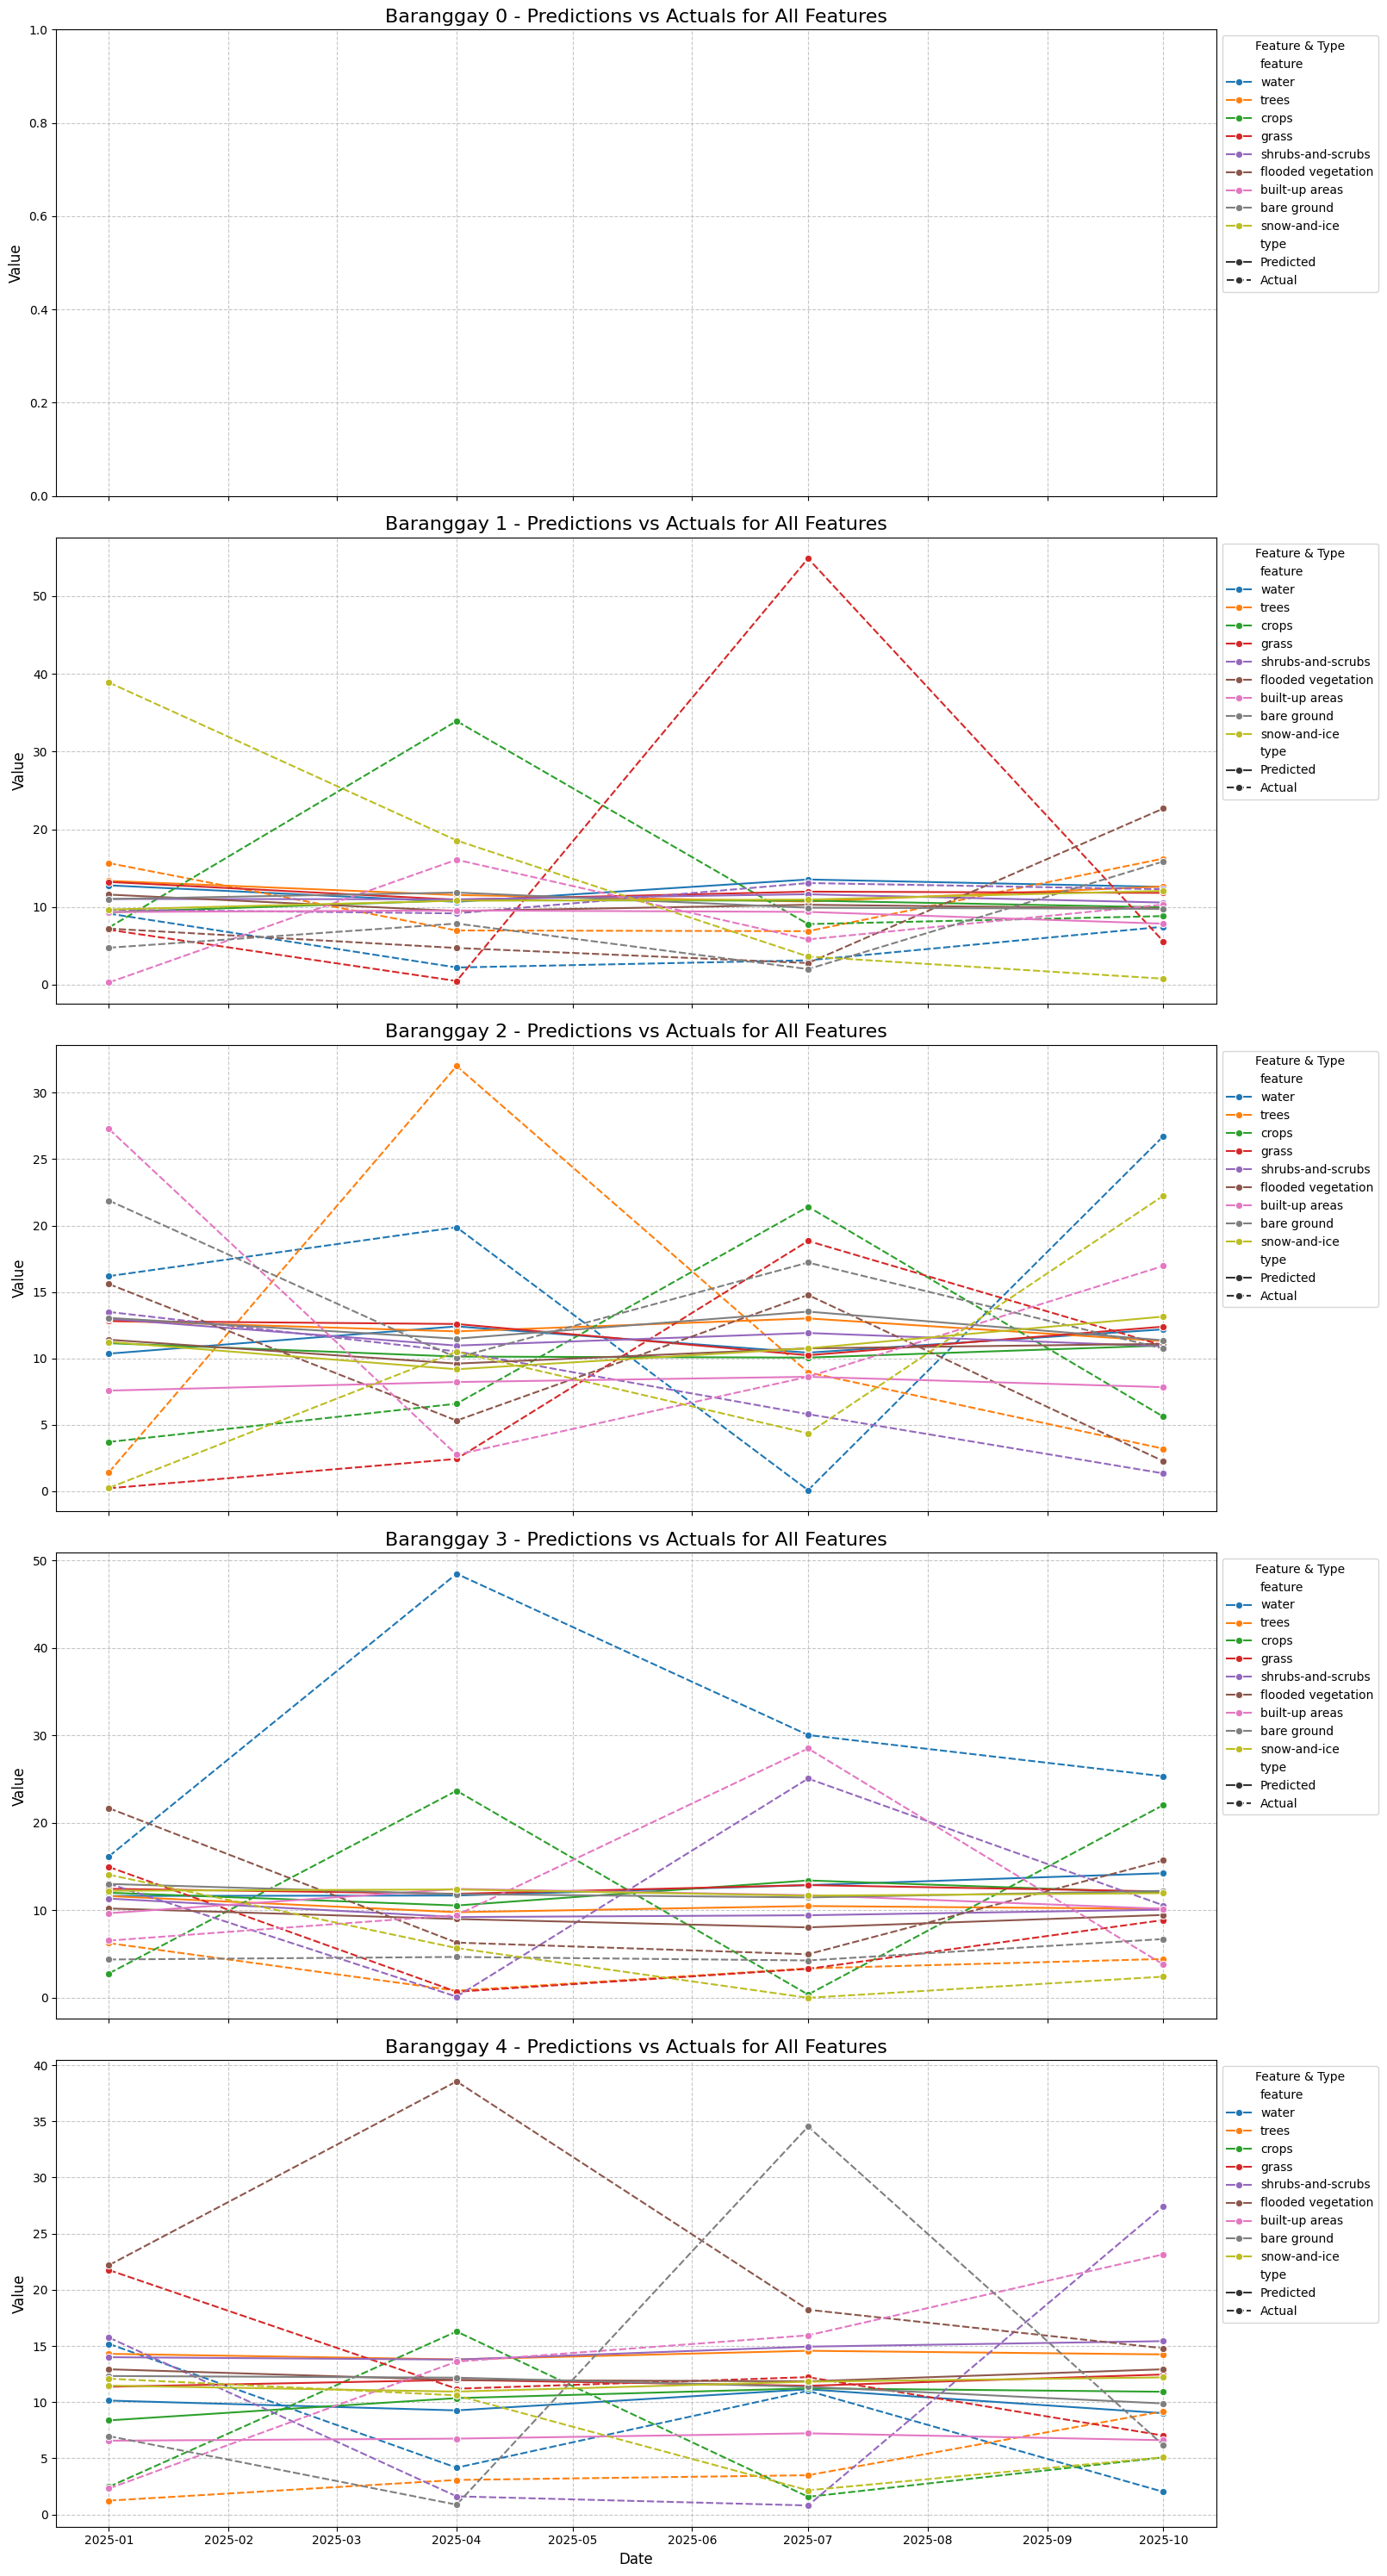

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 1. Extract actual values for comparison
actual_values = torch.stack(prediction_output.x['decoder_target'], dim=-1).cpu().numpy()

# --- DEBUGGING: Inspect prediction_output.x structure ---
print("Type of prediction_output.x:", type(prediction_output.x))
if isinstance(prediction_output.x, dict):
    print("Keys in prediction_output.x:", prediction_output.x.keys())
else:
    print("prediction_output.x is not a dictionary. Its content:", prediction_output.x)
# ---------------------------------------------------------

# 2. Prepare data for plotting
plot_data = []

# Get the baranggay_ids for each prediction series in the batch
# Corrected: Use 'groups' key instead of 'group_ids'
series_baranggay_ids = prediction_output.x['groups'].cpu().numpy().astype(str)

# Get the time_idx for the decoder period for each prediction series
series_decoder_time_idx = prediction_output.x['decoder_time_idx'].cpu().numpy()

# Iterate through each series in the batch to collect data for plotting
for i in range(len(series_baranggay_ids)):
    # Corrected: Access the scalar string from the array
    current_baranggay_id = series_baranggay_ids[i][0]
    current_decoder_time_idx = series_decoder_time_idx[i]

    # Get actual dates for the prediction period from the original 'data' dataframe
    actual_dates_for_series = data[
        (data['baranggay_id'] == current_baranggay_id) &
        (data['time_idx'].isin(current_decoder_time_idx))
    ].sort_values('time_idx')['date'].tolist()

    for t_step in range(max_prediction_length):
        current_date = actual_dates_for_series[t_step] if t_step < len(actual_dates_for_series) else pd.NaT

        for f_idx, feature_name in enumerate(time_series_features):
            predicted_val = mean_predictions[i, t_step, f_idx].item()
            plot_data.append({
                'baranggay_id': current_baranggay_id,
                'date': current_date,
                'feature': feature_name,
                'value': predicted_val,
                'type': 'Predicted'
            })

            actual_val = actual_values[i, t_step, f_idx].item()
            plot_data.append({
                'baranggay_id': current_baranggay_id,
                'date': current_date,
                'feature': feature_name,
                'value': actual_val,
                'type': 'Actual'
            })

plot_df = pd.DataFrame(plot_data)

print("Sample of data prepared for plotting:")
display(plot_df)

# 3. Visualize predictions vs. actuals for each baranggay, with all features on one plot
unique_baranggays = plot_df['baranggay_id'].unique()
num_baranggays = len(unique_baranggays)

fig, axes = plt.subplots(num_baranggays, 1, figsize=(18, 6 * num_baranggays), sharex=True)

if num_baranggays == 1:
    axes = [axes]

for i, baranggay_id_str in enumerate(unique_baranggays):
    subset_df = plot_df[plot_df['baranggay_id'] == baranggay_id_str]

    sns.lineplot(data=subset_df, x='date', y='value', hue='feature', style='type', ax=axes[i], marker='o')

    axes[i].set_title(f'Baranggay {baranggay_id_str} - Predictions vs Actuals for All Features', fontsize=16)
    axes[i].set_ylabel('Value', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend(title='Feature & Type', loc='upper left', bbox_to_anchor=(1, 1))

axes[-1].set_xlabel('Date', fontsize=12)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()